In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Historical VaR & CVaR Analysis

Value at Risk (VaR) estimates the maximum expected loss at a given confidence level. Conditional VaR (CVaR) measures the average loss beyond the VaR threshold.


In [4]:
var_df = pd.read_csv("reports/var_cvar_report.csv")
var_df.head()

,amfi_code,VaR_95_pct,CVaR_95_pct,scheme_name,risk_category
0,100016,-1.436364,-1.806021,HDFC Top 100 Fund - Regular Plan - Growth,Moderate
1,100025,-0.379325,-0.499376,HDFC Short Term Debt Fund - Regular - Growth,Low
2,100033,-1.903354,-2.345576,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
3,101206,-1.328166,-1.743943,ABSL Frontline Equity Fund - Regular - Growth,Moderate
4,101207,-2.602125,-3.245906,ABSL Small Cap Fund - Regular - Growth,Very High


In [15]:
var_df.sort_values("VaR_95_pct").head(10)

,amfi_code,VaR_95_pct,CVaR_95_pct,scheme_name,risk_category
22,119599,-2.685944,-3.238412,SBI Small Cap Fund - Direct Plan - Growth,Very High
17,119095,-2.618842,-3.166729,Axis Small Cap Fund - Regular - Growth,Very High
4,101207,-2.602125,-3.245906,ABSL Small Cap Fund - Regular - Growth,Very High
11,118634,-2.543811,-3.230407,Nippon India Small Cap Fund - Regular - Growth,Very High
21,119598,-2.450705,-3.059526,SBI Small Cap Fund - Regular Plan - Growth,Very High
39,149324,-2.348307,-3.103625,DSP Small Cap Fund - Regular - Growth,Very High
7,102886,-1.922028,-2.325086,UTI Mid Cap Fund - Regular - Growth,High
2,100033,-1.903354,-2.345576,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High
25,120505,-1.889179,-2.434207,ICICI Pru Midcap Fund - Regular - Growth,High
16,119094,-1.848028,-2.426006,Axis Midcap Fund - Regular - Growth,High


In [16]:
cohort = pd.read_csv("reports/cohort_analysis.csv")

In [12]:
sip = pd.read_csv("reports/sip_continuity.csv")

# Rolling 90-Day Sharpe Ratio

Rolling Sharpe Ratio helps evaluate risk-adjusted performance over time.

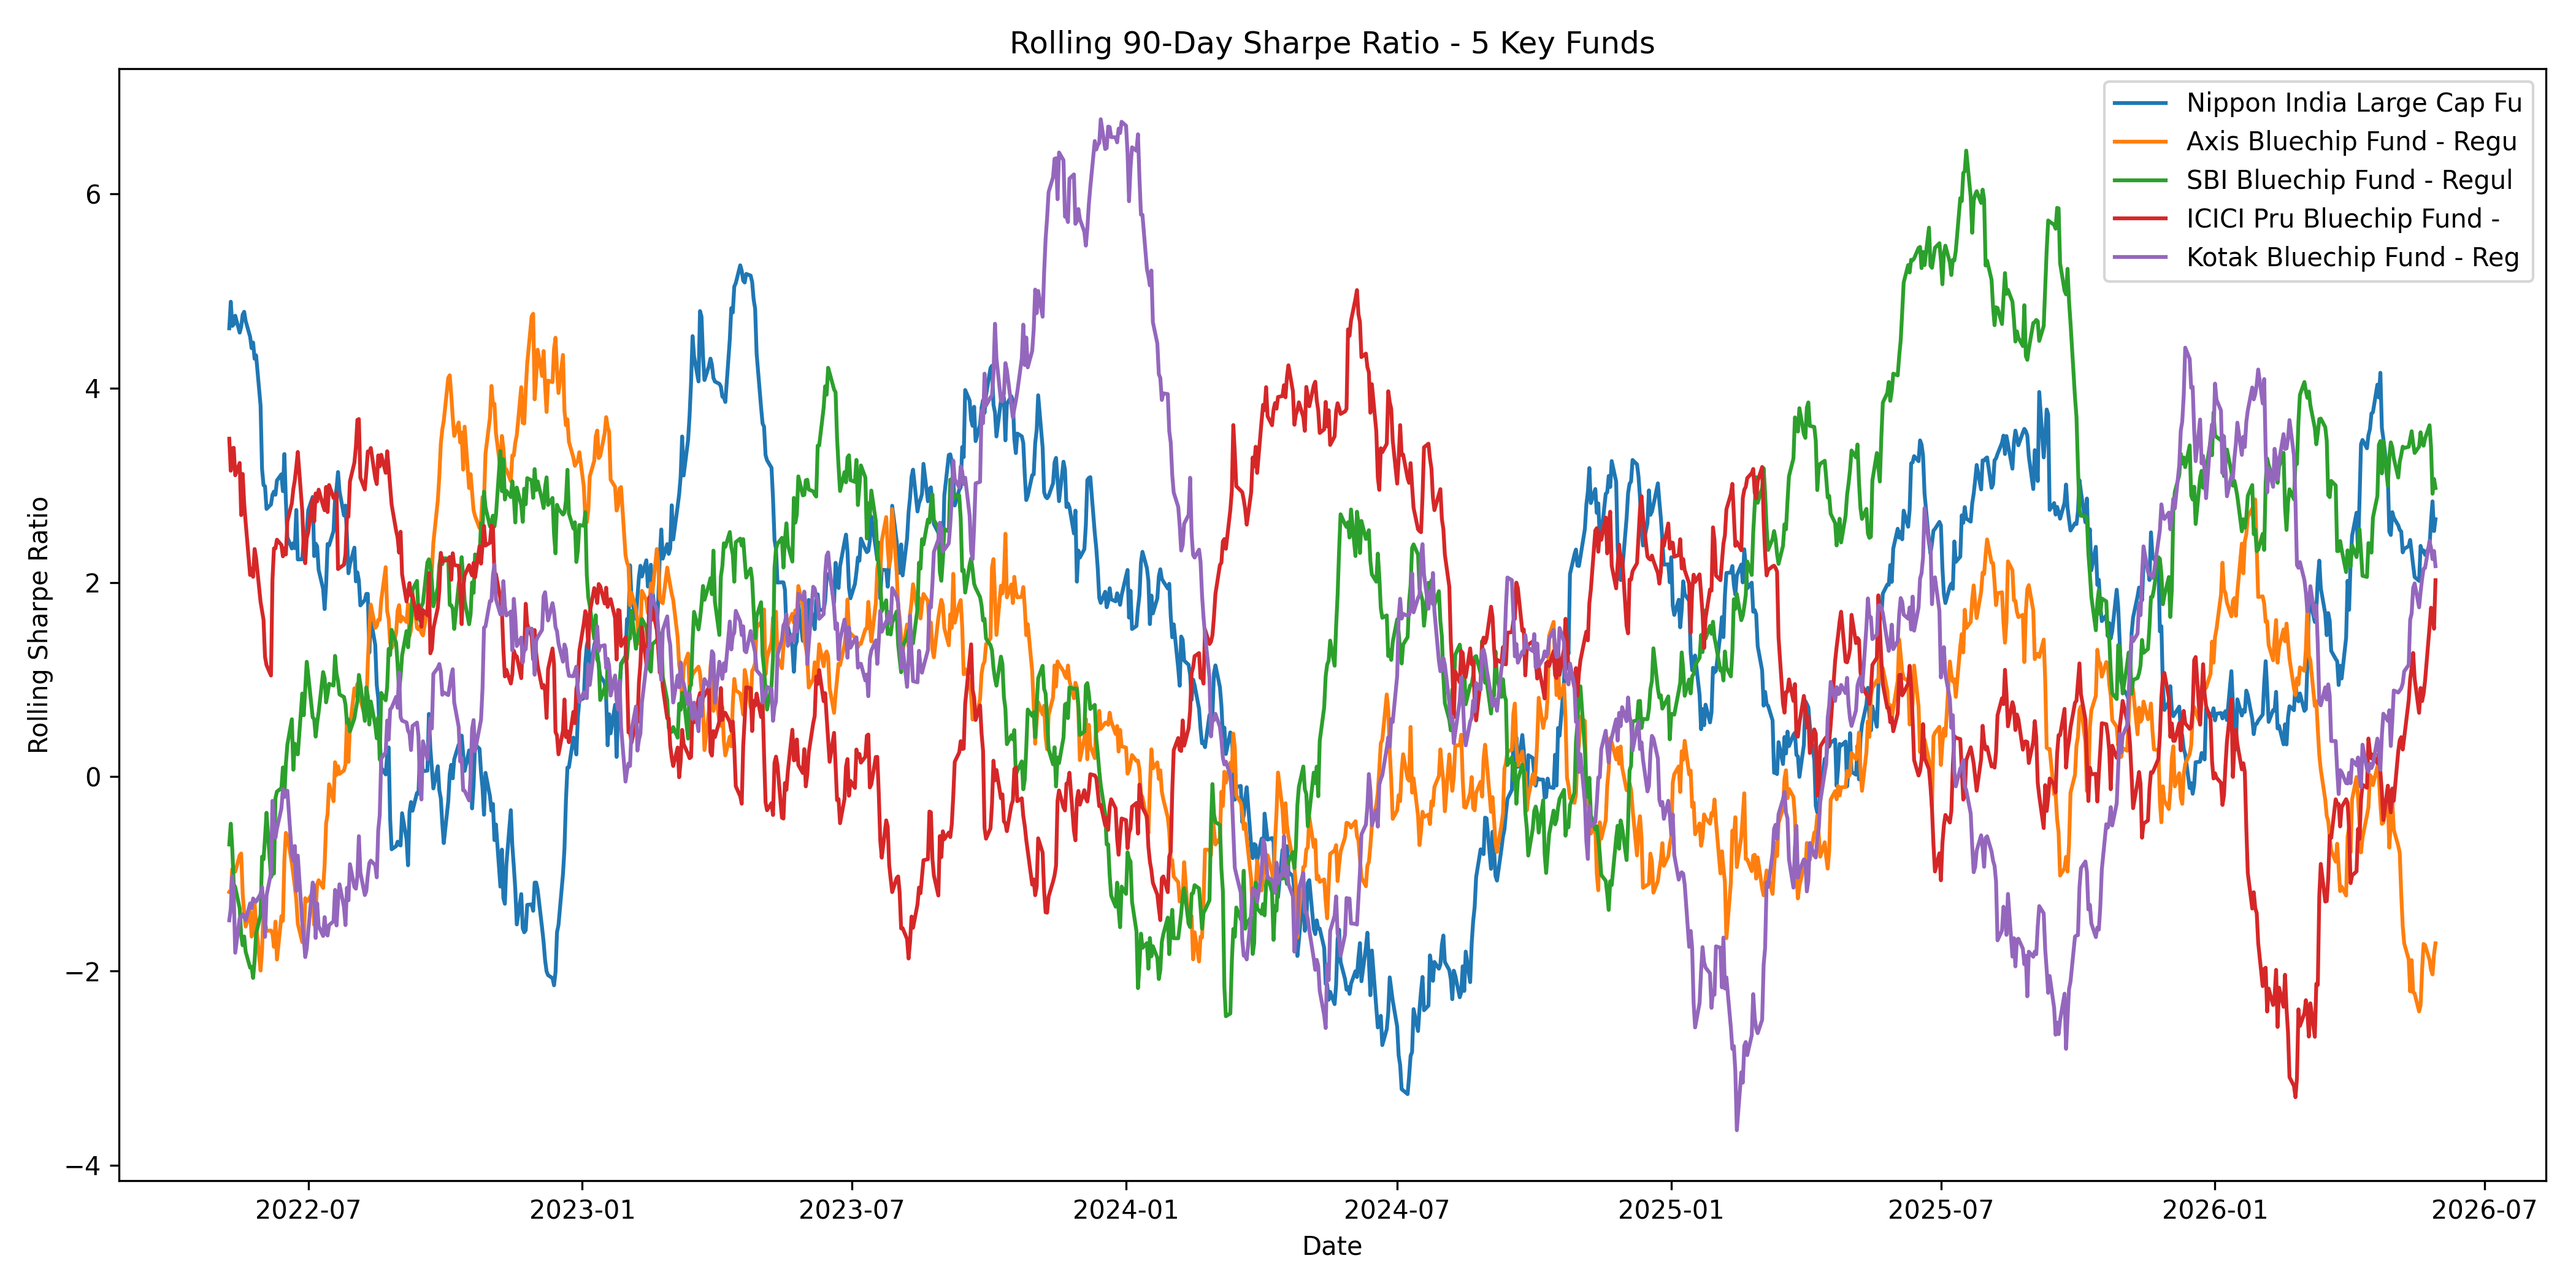

In [13]:
from IPython.display import Image, display

display(Image(filename="reports/rolling_sharpe_chart.png"))

# Investor Cohort Analysis

Investors are grouped based on their first investment year.

In [18]:
cohort = pd.read_csv("reports/cohort_analysis.csv")
cohort

,cohort_year,avg_sip_amount,total_invested,investor_count


# SIP Continuity Analysis

Investors with large gaps between SIP payments are classified as at-risk.

In [19]:
sip = pd.read_csv("reports/sip_continuity.csv")
sip.head()

,investor_id,avg_gap_days,sip_count,total_sip_amount,risk_status


# Fund Recommender System

Top funds are recommended based on risk appetite and Sharpe Ratio.

In [21]:
scorecard = pd.read_csv("reports/fund_scorecard.csv")

scorecard[
    ["scheme_name","sharpe_ratio","final_score"]
].sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

,scheme_name,sharpe_ratio,final_score
0,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,86.2500
2,Kotak Flexicap Fund - Regular - Growth,1.306744,82.0000
7,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,73.6875
6,SBI Bluechip Fund - Regular Plan - Growth,1.208267,74.8125
1,ICICI Pru Midcap Fund - Regular - Growth,1.180101,82.2500
10,DSP Midcap Fund - Regular - Growth,1.132122,66.7500
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,80.7500
12,Nippon India Large Cap Fund - Regular - Growth,1.081659,66.5625
8,ABSL Frontline Equity Fund - Regular - Growth,1.027213,68.1875
4,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,80.0000


# Sector HHI Concentration

Herfindahl-Hirschman Index (HHI) measures concentration risk within a portfolio.

In [22]:
holdings = pd.read_csv("data/processed/09_portfolio_holdings.csv")
funds = pd.read_csv("data/processed/01_fund_master.csv")

# HHI = sum of squared portfolio weights
holdings["weight_decimal"] = holdings["weight_pct"] / 100

hhi = holdings.groupby("amfi_code")["weight_decimal"].apply(
    lambda x: (x ** 2).sum()
).reset_index()

hhi.columns = ["amfi_code", "sector_hhi"]

hhi = hhi.merge(
    funds[["amfi_code", "scheme_name", "fund_house", "category"]],
    on="amfi_code",
    how="left"
)

hhi.sort_values("sector_hhi", ascending=False).head(10)

,amfi_code,sector_hhi,scheme_name,fund_house,category
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Equity
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Equity
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Equity
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Equity
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Equity
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Equity
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Equity
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Equity
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Equity


In [24]:
hhi.to_csv("reports/sector_hhi.csv", index=False)

# Advanced Insights

1. Funds with higher Sharpe Ratios delivered superior risk-adjusted returns.
2. VaR analysis identified the most volatile schemes in the portfolio universe.
3. Rolling Sharpe trends revealed changing market conditions across time.
4. Cohort analysis highlighted differences in investor behaviour across years.
5. SIP continuity analysis identified investors likely to discontinue contributions.